# Лабораторная работа 2. Линейная регрессия

Загрузите датасет auto-mpg.csv из папки datasets

В качестве x возьмите horsepower

В качестве y - mpg

In [69]:
import numpy as np
import pandas as pd

In [70]:
df = pd.read_csv('auto-mpg.csv')
df.head()

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,0,18.0,8,307.0,130.0,3504,12.0,70
1,1,15.0,8,350.0,165.0,3693,11.5,70
2,2,18.0,8,318.0,150.0,3436,11.0,70
3,3,16.0,8,304.0,150.0,3433,12.0,70
4,4,17.0,8,302.0,140.0,3449,10.5,70


In [71]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [ ]:
X = df['horsepower'].to_numpy().reshape(-1, 1)
y = df['mpg'].to_numpy()

# Задание 1

Обучите модели линейной регрессии. Посчитайте метрики MSE, MAE, R^2. Нарисуйте графики предсказанные значения/остатки. Виды моделей:

1. $y = wx$
2. $y = wx+b$
3. $y = wx^2$
4. $y = w/x$
5. $y = wlog(x)$

Какая из этих моделей подходит лучше?

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [90]:
models = [
    ("y = w·x",       lambda x: x,       False),
    ("y = w·x + b",   lambda x: x,       True),
    ("y = w·x²",      lambda x: x**2,    False),
    ("y = w/x",       lambda x: 1/x,     False),
    ("y = w·ln(x)",   lambda x: np.log(x), False),
]

df_metrics = pd.DataFrame(columns=('model', 'MSE', 'MAE', 'R2'))
results = {}

for name, transform, bias in models:
    X_transformed = transform(X)
    lr = LinearRegression(fit_intercept=bias).fit(X_transformed, y)
    y_pred = lr.predict(X_transformed)

    new_row = pd.DataFrame({
        'model': [name],
        'MSE': [mean_squared_error(y, y_pred)],
        'MAE': [mean_absolute_error(y, y_pred)],
        'R2': [r2_score(y, y_pred)],
    })
    df_metrics = pd.concat([df_metrics, new_row], ignore_index=True)

    results[name] = {
        'y_pred': y_pred,
        'residuals': y - y_pred,
    }

df_metrics

,model,MSE,MAE,R2
0,y = w·x,215.574024,12.259395,-2.521167
1,y = w·x + b,24.205952,3.852272,0.604622
2,y = w·x²,390.195473,17.238521,-5.373417
3,y = w/x,21.8246,3.369684,0.643519
4,y = w·ln(x),86.373906,7.750025,-0.410824


По всем метрикам наилучшая модель - $y=w/x$

In [91]:
import matplotlib.pyplot as plt

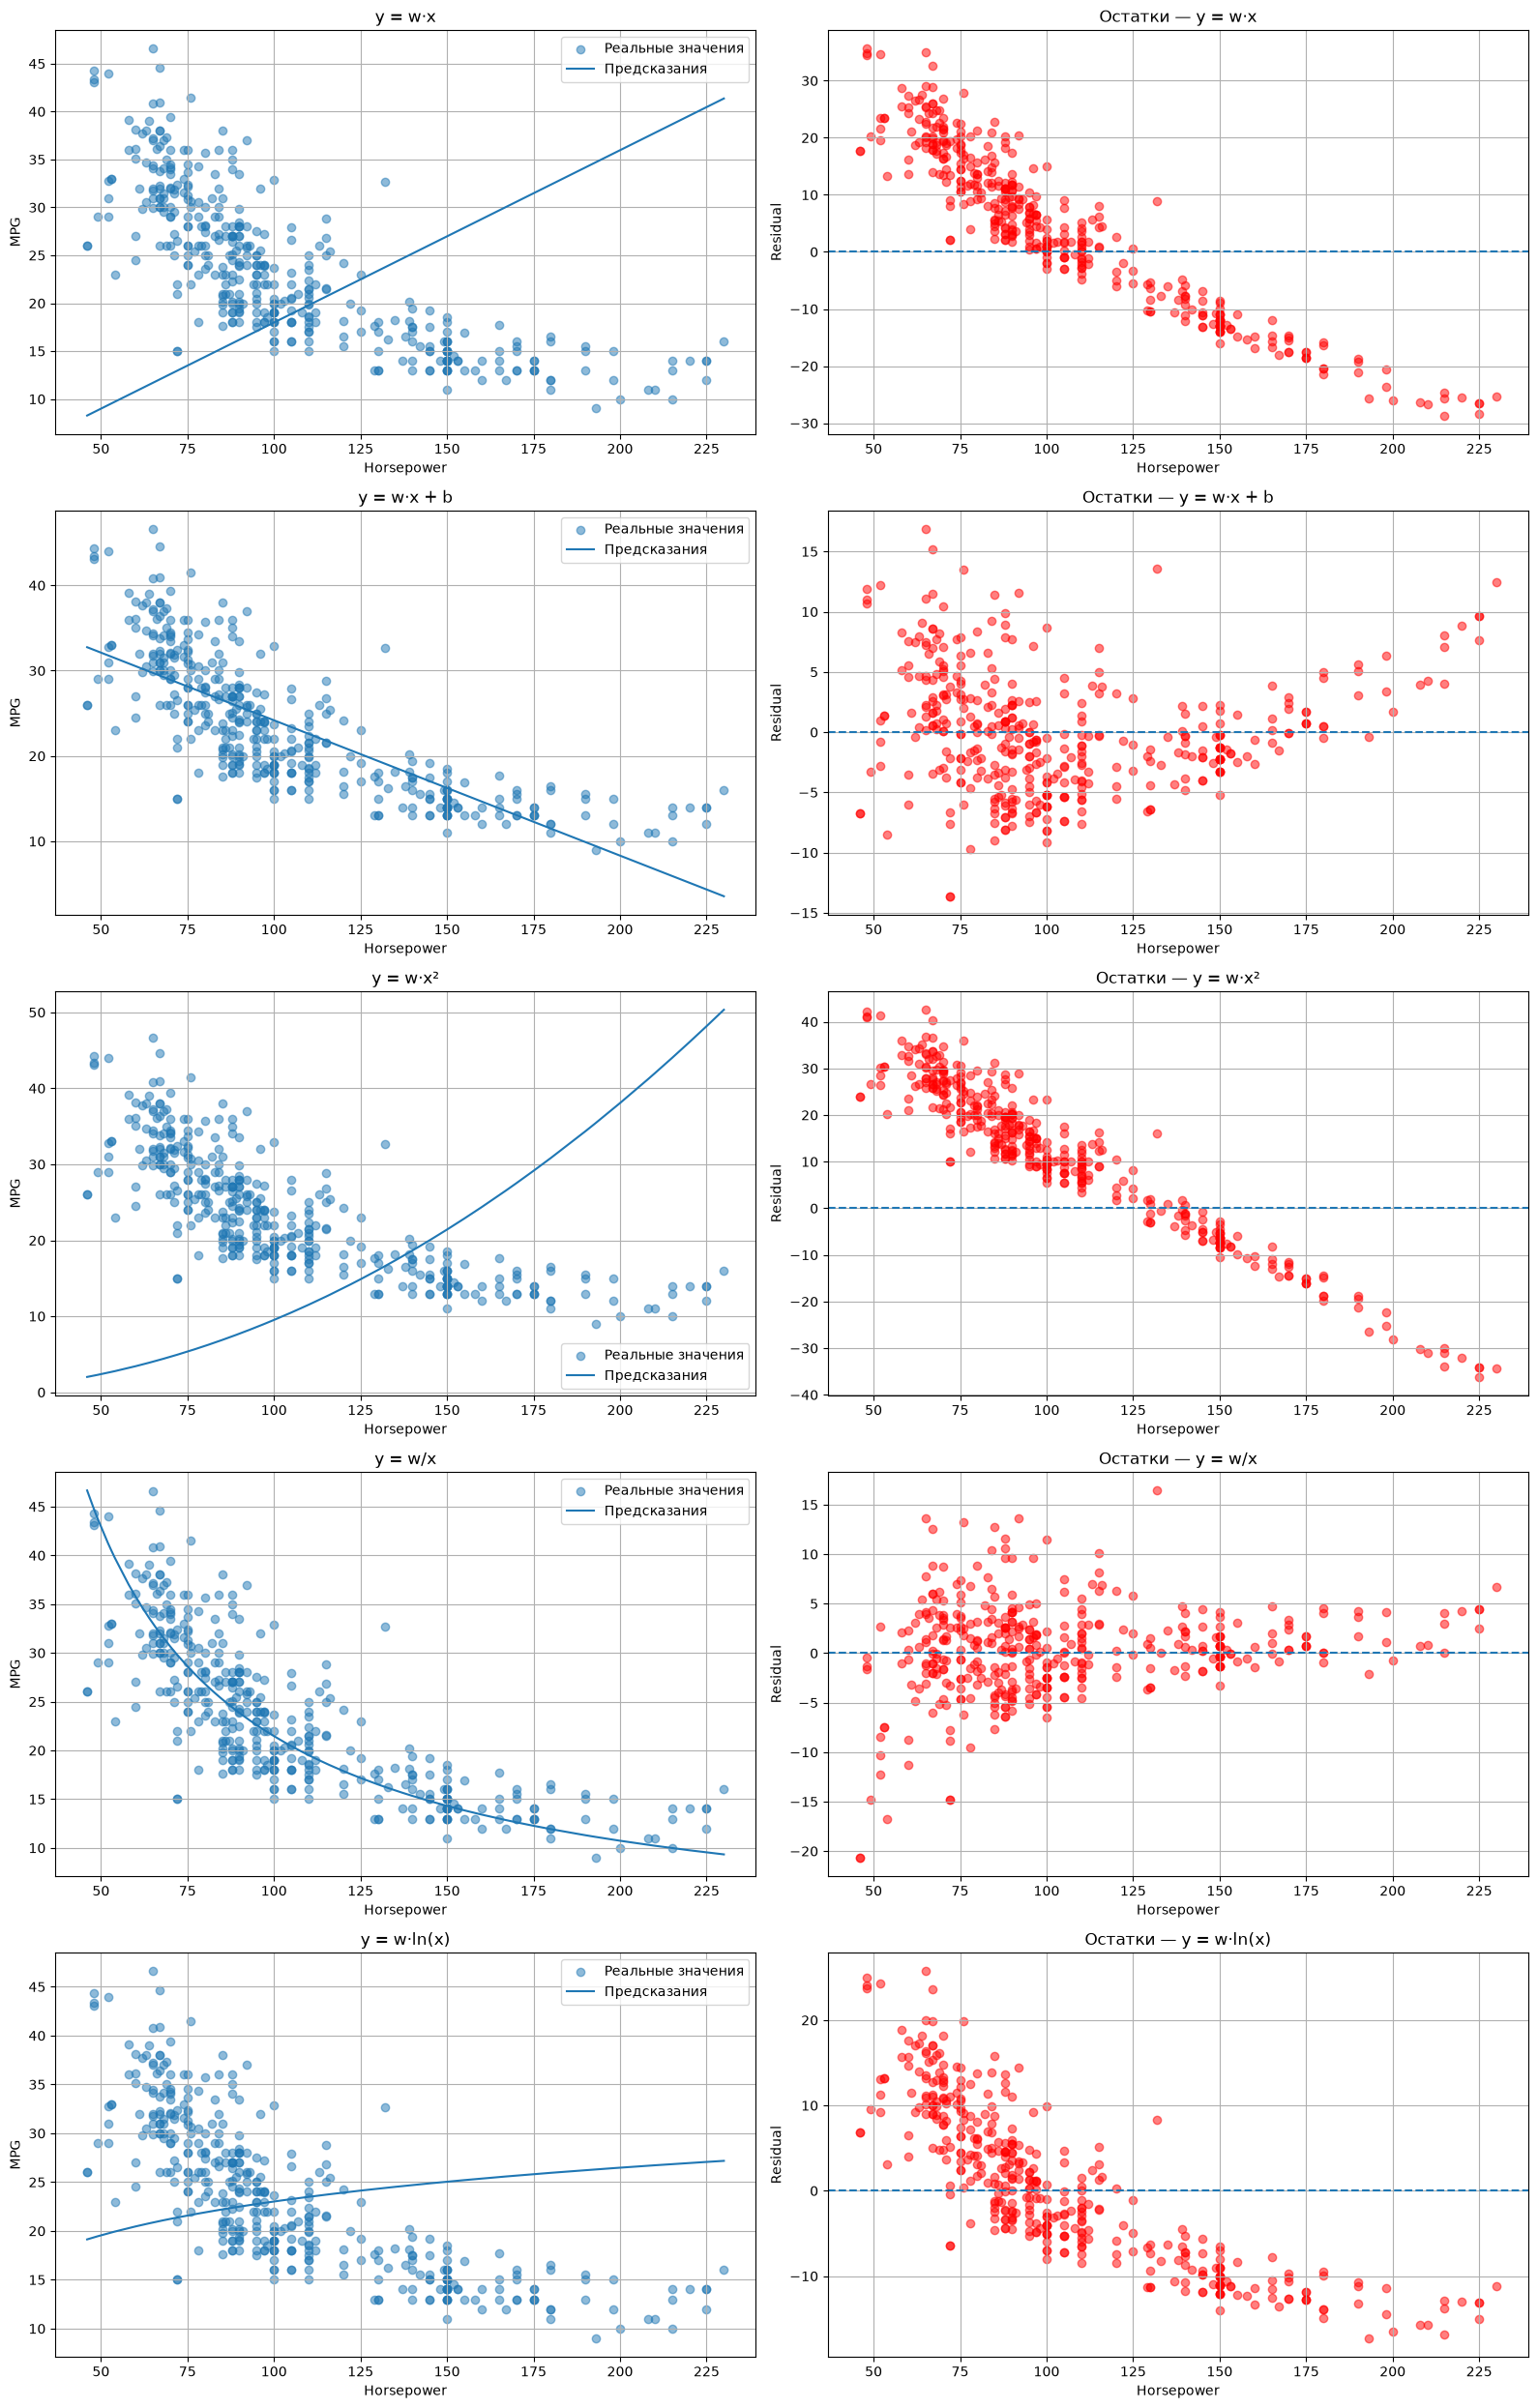

In [94]:
fig, axes = plt.subplots(
    len(results), 2,
    figsize=(16, 25)
)

for row, (name, result) in enumerate(results.items()):

    y_pred = result['y_pred']
    residuals = result['residuals']

    order = np.argsort(X[:, 0])

    axes[row, 0].scatter(
        X[:, 0],
        y,
        alpha=0.5,
        label='Реальные значения'
    )

    axes[row, 0].plot(
        X[order, 0],
        y_pred[order],
        label='Предсказания'
    )

    axes[row, 0].set_title(name)
    axes[row, 0].set_xlabel('Horsepower')
    axes[row, 0].set_ylabel('MPG')
    axes[row, 0].legend()
    axes[row, 0].grid()

    axes[row, 1].scatter(
        X[:, 0],
        residuals,
        alpha=0.5,
        c='red'
    )

    axes[row, 1].axhline(
        0,
        linestyle='--'
    )

    axes[row, 1].set_title(f'Остатки — {name}')
    axes[row, 1].set_xlabel('Horsepower')
    axes[row, 1].set_ylabel('Residual')
    axes[row, 1].grid()


plt.tight_layout()
plt.show()